In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spence

# Step 1: Construct Brillouin Zone

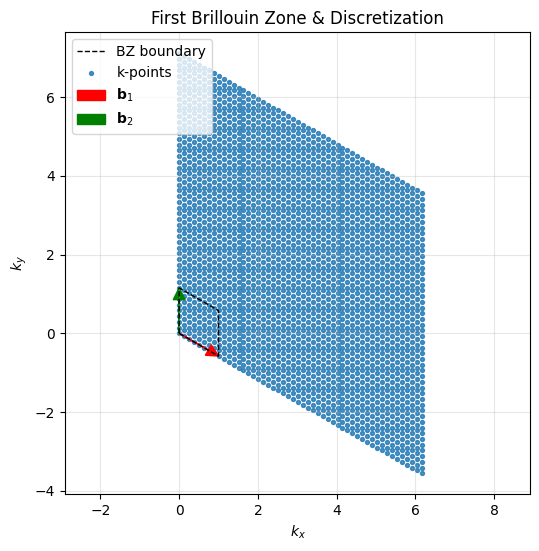

In [128]:
a = 1 # Lattice constant
L1, L2 = 50,50  # You can adjust these for denser/sparser sampling

# Define reciprocal lattice vectors
a1,a2 = a* np.array([1,0]),a* np.array([np.cos(np.pi/3),np.sin(np.pi/3)])
b1 = 2 / (np.sqrt(3) * a) * np.array([np.cos(np.pi / 6), -np.sin(np.pi / 6)])
b2 = 2 / (np.sqrt(3) * a) * np.array([0,1])
# Generate k-points in the 1st Brillouin Zone parallelogram
k_pts = []
for i in range(L1):
    for j in range(L2):
        k = (2*np.pi * i / L1) * b1 + (2*np.pi * j / L2) * b2
        k_pts.append(k)
k_pts = np.array(k_pts)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the parallelogram (BZ) edges
corner = np.array([[0, 0], b1, b1 + b2, b2, [0, 0]])
ax.plot(corner[:, 0], corner[:, 1], 'k--', linewidth=1, label='BZ boundary')

# Plot lattice points in the BZ
ax.scatter(k_pts[:, 0], k_pts[:, 1], s=8, color='C0', alpha=0.8, label='k-points')

# Plot reciprocal lattice vectors
ax.arrow(0, 0, b1[0], b1[1], head_width=0.3, head_length=0.3, fc='r', ec='r', length_includes_head=True, label=r'$\mathbf{b}_1$')
ax.arrow(0, 0, b2[0], b2[1], head_width=0.3, head_length=0.3, fc='g', ec='g', length_includes_head=True, label=r'$\mathbf{b}_2$')

# Formatting
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_title('First Brillouin Zone & Discretization')
ax.axis('equal')
ax.legend(['BZ boundary', 'k-points', r'$\mathbf{b}_1$', r'$\mathbf{b}_2$'], loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Step 2: Compute Matrices $D_k$ from Parameters

In [123]:

from numpy._typing._array_like import NDArray


from typing import Any


theta_a,phi_a = np.arccos(-np.sqrt(2/3)),np.pi/4
theta_nega,phi_nega = np.arccos(np.sqrt(2/3)),5 *np.pi/4
hRatio = 0.2
K, Gamma, GammaPrime = -1,0.2,-0.02

# Takes (0,0,1), and maps to a vector with \phi (in xy plane) and \theta (polar from z axis) spherical coordinates.
def Rot(theta,phi):
    return np.array([[np.cos(theta)*np.cos(phi), - np.sin(phi), np.sin(theta)*np.cos(phi)],
                     [np.cos(theta)*np.sin(phi), np.cos(phi), np.sin(theta)*np.sin(phi)],
                     [-np.sin(theta), 0, np.cos(theta)]])


def Hmats(K,Gamma,GammaPrime):    
    H_x = np.array([[K,GammaPrime,GammaPrime],
                    [GammaPrime,0,Gamma],
                    [GammaPrime,Gamma,0]])
    H_y = np.array([[0,GammaPrime,Gamma],
                    [GammaPrime,K,GammaPrime],
                    [Gamma,GammaPrime,0]])
    H_z = np.array([[0,Gamma,GammaPrime],
                    [Gamma,0,GammaPrime],
                    [GammaPrime,GammaPrime,K]])
    return H_x,H_y,H_z

def HTildeMats(K,Gamma,GammaPrime,theta,phi):

    H_x,H_y,H_z = Hmats(K,Gamma,GammaPrime)
    R = Rot(theta,phi)
    Htilde_x = R.T @ H_x @ R
    Htilde_y = R.T @ H_y @ R
    Htilde_z = R.T @ H_z @ R
    return Htilde_x,Htilde_y,Htilde_z

def deltaLambdas(a1,a2):
    delta_x = 0*a1 -a2 
    delta_y = a1 - a2
    delta_z = 0*a1 + 0*a2
    return delta_x,delta_y,delta_z

# get_grad: 0 for original D_k, 1 for kx partial, 2 for ky partial
def getDk(hRatio,K,Gamma,GammaPrime,theta,phi,a1,a2,get_grad=0):
    h = hRatio * np.abs(K)
    if get_grad == 1 or get_grad == 2: h = 0 # derivative of constant is 0

    Htildes = HTildeMats(K,Gamma,GammaPrime,theta,phi)
    deltas = deltaLambdas(a1,a2)
    zipped_iterable =  list(zip(Htildes, deltas))       

    # k is a (x,y) vector in reciprocal space
    def Dk(k):
        # Construct A_k and B_k
        A_k = np.array([[h,0],[0,h]],dtype=np.complex128)
        A_negk = np.array([[h,0],[0,h]],dtype=np.complex128)
        B_k = np.array([[0,0],[0,0]],dtype=np.complex128)
        B_negk = np.array([[0,0],[0,0]],dtype=np.complex128)
        for Htilde, delta in zipped_iterable:
            h11,h22,h33,h12 = Htilde[0,0],Htilde[1,1],Htilde[2,2], Htilde[0,1]
            exponent_pos = np.exp(1j * np.dot(k,delta))
            exponent_neg = np.exp(-1j * np.dot(k,delta))

            if get_grad == 1:
                exponent_pos *= 1j * delta[0]
                exponent_neg *= -1j * delta[0]
                h33 = 0 # derivative of constant is 0
            elif get_grad == 2:
                exponent_pos *= 1j * delta[1]
                exponent_neg *= -1j * delta[1]
                h33 = 0 # derivative of constant is 0
            

            next_term_A_k = np.array([[-h33, 1/2 * (h11 + h22) * exponent_pos],
                                     [1/2 * (h11 + h22) * exponent_neg, -h33]],dtype=np.complex128)
            
            next_term_B_k = 1/2 * (h11 + 2j * h12 - h22) * np.array([[0,exponent_pos],
                                                                    [exponent_neg,0]],dtype=np.complex128)
            
            next_term_A_negk = np.array([[-h33, 1/2 * (h11 + h22) * exponent_neg],
                                     [1/2 * (h11 + h22) * exponent_pos, -h33]],dtype=np.complex128)
            
            next_term_B_negk = 1/2 * (h11 + 2j * h12 - h22) * np.array([[0,exponent_neg],
                                                                    [exponent_pos,0]],dtype=np.complex128)
            
            A_k += next_term_A_k
            B_k += next_term_B_k
            A_negk += next_term_A_negk
            B_negk += next_term_B_negk
        

        # Construct D_k block diagonals with A_k, and off block diagonasl with B_k
        D_k = np.block([[A_k,B_k],[B_negk.conj(),A_negk.T]])

        return D_k
    
    return Dk


# Returns two arrays: eigenvalues and eigenvectors, in that order
# Eigenvalues is 1D array, two values, which are the sorted eigenvalues
# Eigenvectors is 2D, 4x2 array, each column a 4-element vector for the corresponding eigenvalue
# Will get all 4 Eigenvalues if set getall=True 2 should be negative, 2 should be positive
def getDkEigs(Dk,k,getall=False):
    sigma3 = np.diag([1, 1, -1, -1])
    vals, vecs = np.linalg.eig(sigma3 @ Dk(k))
    vals = np.real_if_close(vals, tol=1000)
    vals_real = np.real(vals)

    if getall:
        eigpos_idx = np.arange(4)
    else:
        eigpos_idx = np.where(vals_real > 1e-10)[0]
        if eigpos_idx.size != 2:
            raise RuntimeError(f"Expected 2 positive magnon modes at k={k}, got {vals_real[eigpos_idx]}")

    order = np.argsort(vals_real[eigpos_idx])
    sel = eigpos_idx[order]
    final_vals, final_vecs = vals_real[sel], vecs[:, sel].astype(np.complex128, copy=True)

    # Paraunitary normalization with sigma3 metric: v^dagger sigma3 v = sign(eigenvalue)
    for j in range(final_vecs.shape[1]):
        v = final_vecs[:, j]
        metric_norm = np.real_if_close(np.conj(v).T @ sigma3 @ v, tol=1000)
        metric_norm = np.real(metric_norm)
        if np.abs(metric_norm) < 1e-12:
            raise RuntimeError(f"Near-zero sigma3 norm eigenvector at k={k}, band index={sel[j]}")

        v = v / np.sqrt(np.abs(metric_norm))
        # metric_after = np.real(np.conj(v).T @ sigma3 @ v)
        # target_sign = 1.0 if final_vals[j] > 0 else -1.0
        # if metric_after * target_sign < 0:
        #     v = 1j * v

        final_vecs[:, j] = v

    return final_vals, final_vecs


# Sanity check the identity from the proof in the paper (D_k^-a = D_-k^-a*)
Dk_a = getDk(hRatio,K,Gamma,GammaPrime,theta_a,phi_a,a1,a2)
Dk_nega = getDk(hRatio,K,Gamma,GammaPrime,theta_nega,phi_nega,a1,a2)
dk_a = Dk_a((3,4.5))
d_negk_nega_conj = np.conj(Dk_nega((-3,-4.5)))

# Should be extremely small, element-wise difference absolute value sum
print(np.sum(np.abs(dk_a - d_negk_nega_conj)))

1.493665551027508e-15


In [124]:
# Debug stuff

a_vec = (Rot(theta_a,phi_a) @ np.array([0,0,1]))
a_vec /= np.abs(a_vec[0])
# print(a_vec) # Should be (1,1,-2)

nega_vec = (Rot(theta_nega,phi_nega) @ np.array([0,0,1]))
nega_vec /= np.abs(nega_vec[0])
# print(nega_vec)  # Should be (-1,-1,2)

# Step 3: Compute Dispersion

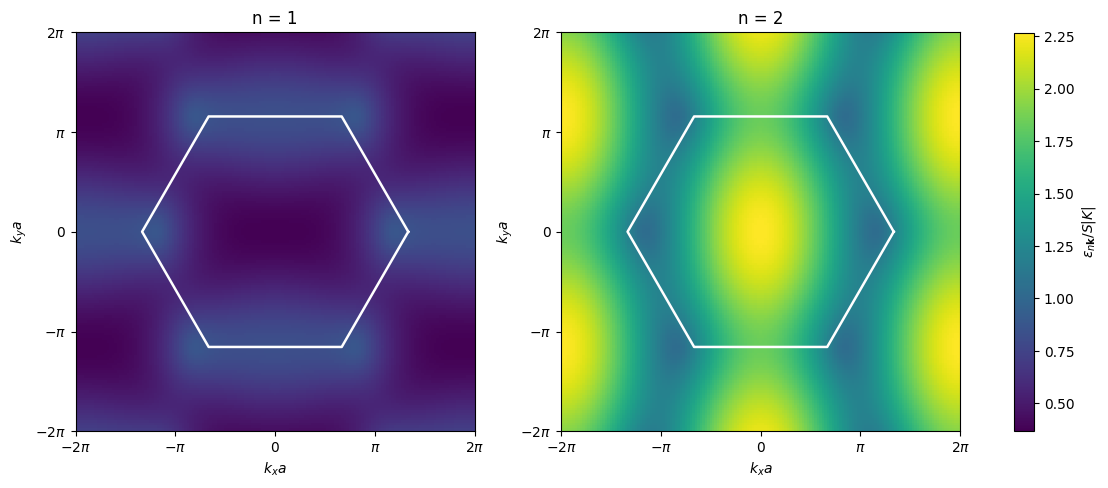

(array([0.72950519, 0.72941073, 0.72912849, ..., 0.72912849, 0.72941073,
        0.72950519], shape=(25921,)),
 array([1.92805522, 1.92703164, 1.92396412, ..., 1.92396412, 1.92703164,
        1.92805522], shape=(25921,)))

In [125]:
def plot(func1,func2,cmap="viridis",hexcolor="white"):

    # Optional plotting grid for Figure 3-style dispersion maps
    # Cartesian reciprocal-space grid with axes shown as k_x a and k_y a in [-2π, 2π]
    Nkx, Nky = 161, 161
    kx_a_vals = np.linspace(-2 * np.pi, 2 * np.pi, Nkx)
    ky_a_vals = np.linspace(-2 * np.pi, 2 * np.pi, Nky)
    KX_a, KY_a = np.meshgrid(kx_a_vals, ky_a_vals, indexing='xy')

    # Dk expects k in units of 1/a
    plotkpts = np.column_stack([(KX_a / a).ravel(), (KY_a / a).ravel()])

    fig3_ticks = np.array([-2 * np.pi, -np.pi, 0.0, np.pi, 2 * np.pi])
    fig3_ticklabels = [r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$', r'$2\pi$']

    vals1,vals2 = np.zeros(len(plotkpts), dtype=np.float64),np.zeros(len(plotkpts), dtype=np.float64)
    for i, k in enumerate(plotkpts):
        val1,val2 = func1(k),func2(k)
        vals1[i],vals2[i] = val1,val2
       
    en1 = vals1.reshape(Nky, Nkx)
    en2 = vals2.reshape(Nky, Nkx)

    # First-BZ hexagon from reciprocal primitive vectors B1=2π b1, B2=2π b2
    B1 = 2 * np.pi * b1
    B2 = 2 * np.pi * b2
    hex_vertices = np.array([
        (2 * B1 + B2) / 3,
        (B1 + 2 * B2) / 3,
        (-B1 + B2) / 3,
        -(2 * B1 + B2) / 3,
        -(B1 + 2 * B2) / 3,
        (B1 - B2) / 3,
    ])
    hex_plot = np.vstack([hex_vertices, hex_vertices[0]]) * a  # axes are k_x a, k_y a

    vmin = min(np.min(en1), np.min(en2))
    vmax = max(np.max(en1), np.max(en2))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)
    im0 = axes[0].pcolormesh(KX_a, KY_a, en1, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].pcolormesh(KX_a, KY_a, en2, shading='auto', cmap=cmap, vmin=vmin, vmax=vmax)

    for ax, n in zip(axes, [1, 2]):
        ax.plot(hex_plot[:, 0], hex_plot[:, 1], color=hexcolor, linewidth=1.8)
        ax.set_xlim(-2 * np.pi, 2 * np.pi)
        ax.set_ylim(-2 * np.pi, 2 * np.pi)
        ax.set_xticks(fig3_ticks, fig3_ticklabels)
        ax.set_yticks(fig3_ticks, fig3_ticklabels)
        ax.set_xlabel(r'$k_x a$')
        ax.set_ylabel(r'$k_y a$')
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(rf'n = {n}')

    cbar = fig.colorbar(im0, ax=axes, shrink=0.92)
    cbar.set_label(r'$\epsilon_{n\mathbf{k}}/S|K|$')
    plt.show()

    return vals1,vals2

# [0] for the eigenvalues, [2] and [3] for the 1st and 2nd POSITIVE eigenvalues (remember 4 total, 2 positive, 2 negative)
plot(lambda k: getDkEigs(Dk_a,k,True)[0][2],lambda k: getDkEigs(Dk_a,k,True)[0][3])

# Step 4: Compute Berry Curvature

In [1]:
gradx_Dk_a = getDk(hRatio,K,Gamma,GammaPrime,theta_a,phi_a,a1,a2,1)
grady_Dk_a = getDk(hRatio,K,Gamma,GammaPrime,theta_a,phi_a,a1,a2,2)

# Berry Curvature in Z direction, at a k, for band n (sorted)
# So for first physical band, n=2, for second physical band, n=3. n = 0,1 are negative eigenvalue bands
def berryCurvatureZ(n,k,Dk,gradx_Dk,grady_Dk):
    sign_metric  = np.diag([-1, -1, 1, 1]) # Not strictly sigma3, need the negatives to pair with the negative eigenvalues/holes, and are in front since you sorted them. 
    eigvals,eigvecs = getDkEigs(Dk,k,True)
    totalBands = eigvals.size

    omega_nk = 0
    for m in range(totalBands):
        if m == n:
            continue
        else:
            numerator = (np.conj(eigvecs[:,n].T) @ gradx_Dk(k) @ eigvecs[:,m]) * (np.conj(eigvecs[:,m].T) @ grady_Dk(k) @ eigvecs[:,n])
            denominator = (eigvals[n] - eigvals[m]) ** 2
            sign = sign_metric[m][m]
            omega_nk += numerator / denominator * sign

    omega_nk = -2 * np.imag(omega_nk)
    return omega_nk
    
berryCurvatureZ(2,(0,1),Dk_a,gradx_Dk_a,grady_Dk_a)

plot(lambda k: berryCurvatureZ(2,k,Dk_a,gradx_Dk_a,grady_Dk_a),lambda k: berryCurvatureZ(3,k,Dk_a,gradx_Dk_a,grady_Dk_a),cmap="seismic",hexcolor="black")

NameError: name 'getDk' is not defined

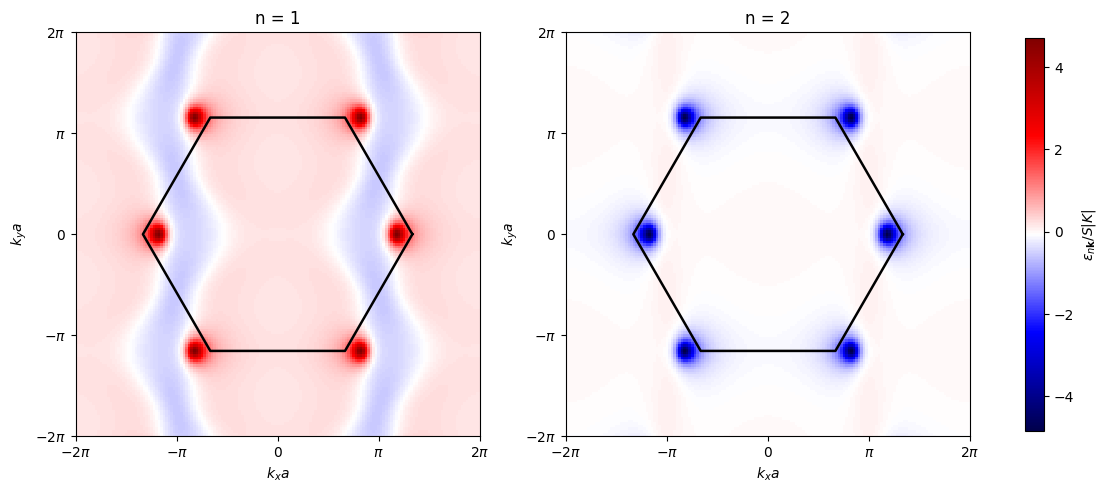

In [73]:
gradx_Dk_nega = getDk(K,Gamma,GammaPrime,theta_nega,phi_nega,a1,a2,1)
grady_Dk_nega = getDk(K,Gamma,GammaPrime,theta_nega,phi_nega,a1,a2,2)
plot(lambda k: berryCurvatureZ(2,k,Dk_nega,gradx_Dk_nega,grady_Dk_nega),lambda k: berryCurvatureZ(3,k,Dk_nega,gradx_Dk_nega,grady_Dk_nega),cmap="seismic",hexcolor="black")

# Step 5: Compute Hall Conductivity (Sum Berry Curvature over BZ)

k-point loop: 100%|██████████| 2500/2500 [00:01<00:00, 1379.60it/s]


Chern numbers: [ 0.          0.         -1.00000085  1.00000085]
Temp: 1, kxy: 0.00033052846714392756


k-point loop: 100%|██████████| 2500/2500 [00:01<00:00, 1432.95it/s]


Chern numbers: [ 0.          0.         -1.00000085  1.00000085]
Temp: 2, kxy: 0.010993244050665592


k-point loop: 100%|██████████| 2500/2500 [00:01<00:00, 1420.79it/s]


...

Chern numbers: [ 0.          0.         -1.00000085  1.00000085]
Temp: 17, kxy: 0.4165844108969189


k-point loop: 100%|██████████| 2500/2500 [00:01<00:00, 1448.98it/s]


Chern numbers: [ 0.          0.         -1.00000085  1.00000085]
Temp: 18, kxy: 0.41086611487159574


k-point loop: 100%|██████████| 2500/2500 [00:01<00:00, 1437.53it/s]

Chern numbers: [ 0.          0.         -1.00000085  1.00000085]
Temp: 19, kxy: 0.4040971001731366


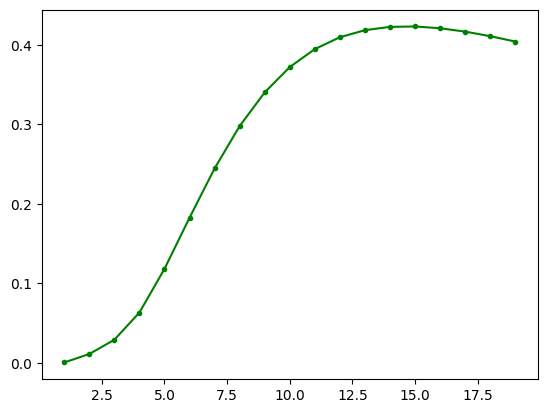

In [130]:
from tqdm.auto import tqdm

# Interlayer distance is 5.72 Angstrom
d = 5.72e-10
area2d = a1[0] * a2[1] - a1[1] * a2[0]
# print(area2d,np.sqrt(3)/2*a) # Debug, check they are the same
V = d * (L1 * L2) # Volume of the whole Crystal Domain
kB = 1.380649e-23

def c2(x):
    return (1+x) * (np.log((1+x)/x))**2 - np.log(x)**2 - 2*spence(1+x)

def g(x,T):
    return 1 / (np.exp(x/(kB*T) )-1)

def singlek(e_nk,omega_nk,T):

    return (c2(g(e_nk,T)) - np.pi**2/3) * omega_nk

def thermallhallconductivity(kpts,hRatio,T,K,Gamma,GammaPrime,theta,phi,a1,a2):
    hbar = 1.054571817e-34
    kB = 1.380649e-23
    d = 5.72e-10


    area2d = np.abs(a1[0] * a2[1] - a1[1] * a2[0])
    V = d * len(kpts) * area2d
    deltaA_k = (2 * np.pi) ** 2 / (len(kpts) * area2d)

    Dk = getDk(hRatio,K,Gamma,GammaPrime,theta,phi,a1,a2)
    gradx_Dk = getDk(hRatio,K,Gamma,GammaPrime,theta,phi,a1,a2,1)
    grady_Dk = getDk(hRatio,K,Gamma,GammaPrime,theta,phi,a1,a2,2)
    
    k_iter = tqdm(kpts, total=len(kpts), desc="k-point loop")

    kappa_xy = 0
    chern_numbers = [0,0,0,0]
    for kx,ky in k_iter:
        k = (kx,ky)
        e_nks = getDkEigs(Dk,k,True)[0]
        for i in range(len(e_nks)):
            enk = e_nks[i]
            enk *= 40 * kB
            if enk > 0:
                omega_nk = berryCurvatureZ(i,k,Dk,gradx_Dk,grady_Dk)
                kappa_xy += singlek(enk,omega_nk,T)
                chern_numbers[i] += omega_nk * deltaA_k

    kappa_xy *= - kB**2 * T / (V * hbar)

    chern_numbers = np.array(chern_numbers) / (2 * np.pi) 

    return kappa_xy, chern_numbers

T = 10
temps = np.arange(1,20,1)

hRatio = 0.1
K, Gamma, GammaPrime = -1,0.2,-0.02

kxy_list = []
for temp in temps:
    kxy,chern_numbers = thermallhallconductivity(k_pts,hRatio,temp,K,Gamma,GammaPrime,theta_a,phi_a,a1,a2)
    print(f"Chern numbers: {chern_numbers}")
    kxy_list.append(kxy/temp * 1e3)
    print(f"Temp: {temp}, kxy: {kxy/temp * 1e3}")

plt.plot(temps,kxy_list,".-", color="green")
plt.show()

/var/folders/3g/_3rm6vns4x97gc_975bhn77c0000gn/T/ipykernel_2956/913174019.py:25: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  V = d * len(kpts) * np.cross(a1,a2)
k-point loop:   0%|          | 0/900 [00:00<?, ?it/s]/var/folders/3g/_3rm6vns4x97gc_975bhn77c0000gn/T/ipykernel_2956/913174019.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 / (np.exp(x/(kB*T) )-1)
/var/folders/3g/_3rm6vns4x97gc_975bhn77c0000gn/T/ipykernel_2956/913174019.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  return (1+x) * (np.log((1+x)/x))**2 - np.log(x)**2 - 2*spence(1+x)
/var/folders/3g/_3rm6vns4x97gc_975bhn77c0000gn/T/ipykernel_2956/913174019.py:11: RuntimeWarning: divide by zero encountered in log
  return (1+x) * (np.log((1+x)/x))**2 - np.log(x)**2 - 2*spence(1+x)
/var/folders/3g/_3rm6vns4x97gc_975bhn77c0000gn/T/ipykernel_2956/913174019.py:11: RuntimeWarning: invali

Temp: 0, kxy: nan


k-point loop: 100%|██████████| 900/900 [00:00<00:00, 1428.79it/s]


Temp: 1, kxy: 0.1901031466713199


k-point loop: 100%|██████████| 900/900 [00:00<00:00, 1349.12it/s]


...

Temp: 17, kxy: -0.31099456329760733


k-point loop: 100%|██████████| 900/900 [00:00<00:00, 1472.82it/s]


Temp: 18, kxy: -0.30746852871644625


k-point loop: 100%|██████████| 900/900 [00:00<00:00, 1464.84it/s]

Temp: 19, kxy: -0.30267425915886237


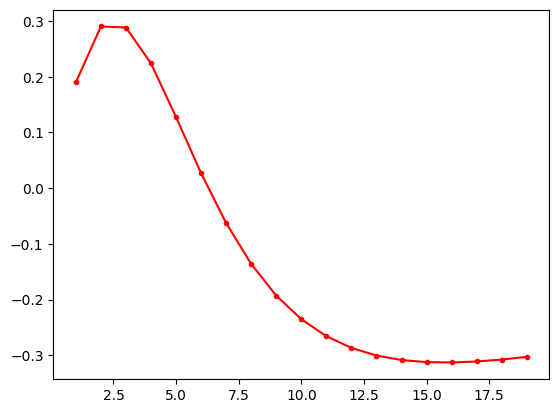

In [113]:
temps = np.arange(0,20,1)
hRatio = 0.1
K, Gamma, GammaPrime = -1,0.2,-0.02
kxy_list = []
for temp in temps:
    kxy = thermallhallconductivity(k_pts,hRatio,temp,K,Gamma,GammaPrime,theta_nega,phi_nega,a1,a2)
    kxy_list.append(kxy/temp * 1e3)
    print(f"Temp: {temp}, kxy: {kxy/temp * 1e3}")

plt.plot(temps,kxy_list,".-", color="red")
plt.show()